In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('kitsune_2M.csv/kitsune_2M.csv')
df.head()

,0,1,2,3,4,5,6,7,8,9,...,106,107,108,109,110,111,112,113,114,category
0,375.315679,1326.511418,201903.072658,592.000967,1329.897740,197192.169079,1705.020717,1335.540577,189296.037162,16883.939557,...,0.000000,0.000000,27772.556630,1340.507192,426.350748,1340.507192,181774.960584,0.00000,0.000000,2
1,66.001664,1420.782522,33315.971713,102.127235,1412.244567,42483.696664,278.550669,1408.508622,42309.409821,2666.806587,...,0.023465,0.000842,14714.070675,1405.683949,197.501977,1406.965650,39007.031668,-3.73924,-0.007035,3
2,166.174139,1320.891927,206869.209185,284.874171,1328.457989,198282.756793,852.996695,1336.558129,188340.972820,8431.003595,...,0.000000,0.000000,28023.475693,1341.911787,424.410040,1341.911787,180123.881648,0.00000,0.000000,1
3,183.431113,1298.878109,150826.967100,292.369158,1295.720536,148288.116862,866.078344,1296.309897,142381.040636,8704.044562,...,0.000000,0.000000,27887.880217,1335.340814,426.292144,1335.340814,181724.992048,0.00000,0.000000,2
4,203.083825,1339.740636,192538.799906,310.301412,1336.227427,192690.592487,863.699881,1336.703697,187865.770436,8430.275303,...,0.000000,0.000000,28008.115206,1341.801667,424.515041,1341.801667,180213.020088,0.00000,0.000000,1


In [3]:
df.info(verbose=True, show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 2000001 entries, 0 to 2000000
Data columns (total 116 columns):
 #    Column    Non-Null Count    Dtype  
---   ------    --------------    -----  
 0    0         2000001 non-null  float64
 1    1         2000001 non-null  float64
 2    2         2000001 non-null  float64
 3    3         2000001 non-null  float64
 4    4         2000001 non-null  float64
 5    5         2000001 non-null  float64
 6    6         2000001 non-null  float64
 7    7         2000001 non-null  float64
 8    8         2000001 non-null  float64
 9    9         2000001 non-null  float64
 10   10        2000001 non-null  float64
 11   11        2000001 non-null  float64
 12   12        2000001 non-null  float64
 13   13        2000001 non-null  float64
 14   14        2000001 non-null  float64
 15   15        2000001 non-null  float64
 16   16        2000001 non-null  float64
 17   17        2000001 non-null  float64
 18   18        2000001 non-null  float64
 19   19       

In [4]:
y = df['category']
X = df.drop(columns=['category'])


In [5]:
y.value_counts()

category
0    400005
1    400000
4    400000
2    399998
3    399998
Name: count, dtype: int64

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
"""
0 - Benign
1 - Reconnaissance
2 - Man in the Middle
3 - Denial of Service
4 - Botnet Malware
"""
from typing import Any


from sklearn.ensemble import RandomForestClassifier
import joblib # Do zapisywania modeli
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

attack_types = {
    1:"Reconnaissance",
    2:"Man in the Middle",
    3:"Denial of Service",
    4:"Botnet Malware"
}

results = {} 


for attack_id, attack_name in attack_types.items():
    print(f"--- Trenowanie modelu: Normal vs {attack_name} ---")
    
   
    target_classes = [0, attack_id]
    train_mask = y_train.isin(target_classes)
    
    X_train_special = X_train[train_mask]
    y_train_special = y_train[train_mask]
    
    rf = RandomForestClassifier(n_jobs=-1, random_state=42, class_weight='balanced')
    rf.fit(X_train_special, y_train_special)
    
   
    filename = f'kitsune/kitsune_rf_normal_vs_{attack_name}.joblib'
    joblib.dump(rf, filename)


    y_pred = rf.predict(X_test)
    
    
    cm = confusion_matrix(y_test, y_pred)
    

    y_pred_binary: Any = (y_pred != 0).astype(int) 


    cm_final = pd.crosstab(
        y_test, 
        y_pred_binary, 
        rownames=['True class'], 
        colnames=[f'Model decision ({attack_name})']
    )

    model_labels = {
        0: 'Normal', 
        1: f'Alarm: {attack_name}'
    }
    
    
    cm_readable = cm_final.rename(index=attack_types, columns=model_labels)
    
    
    results[attack_name] = cm_final
    
    print(cm_readable)
    print("\n")


--- Trenowanie modelu: Normal vs Reconnaissance ---
Model decision (Reconnaissance)  Normal  Alarm: Reconnaissance
True class                                                    
0                                 80035                      2
Reconnaissance                        1                  80152
Man in the Middle                   228                  79726
Denial of Service                   911                  79081
Botnet Malware                    17478                  62387


--- Trenowanie modelu: Normal vs Man in the Middle ---
Model decision (Man in the Middle)  Normal  Alarm: Man in the Middle
True class                                                          
0                                    80037                         0
Reconnaissance                       11354                     68799
Man in the Middle                       12                     79942
Denial of Service                      856                     79136
Botnet Malware                      

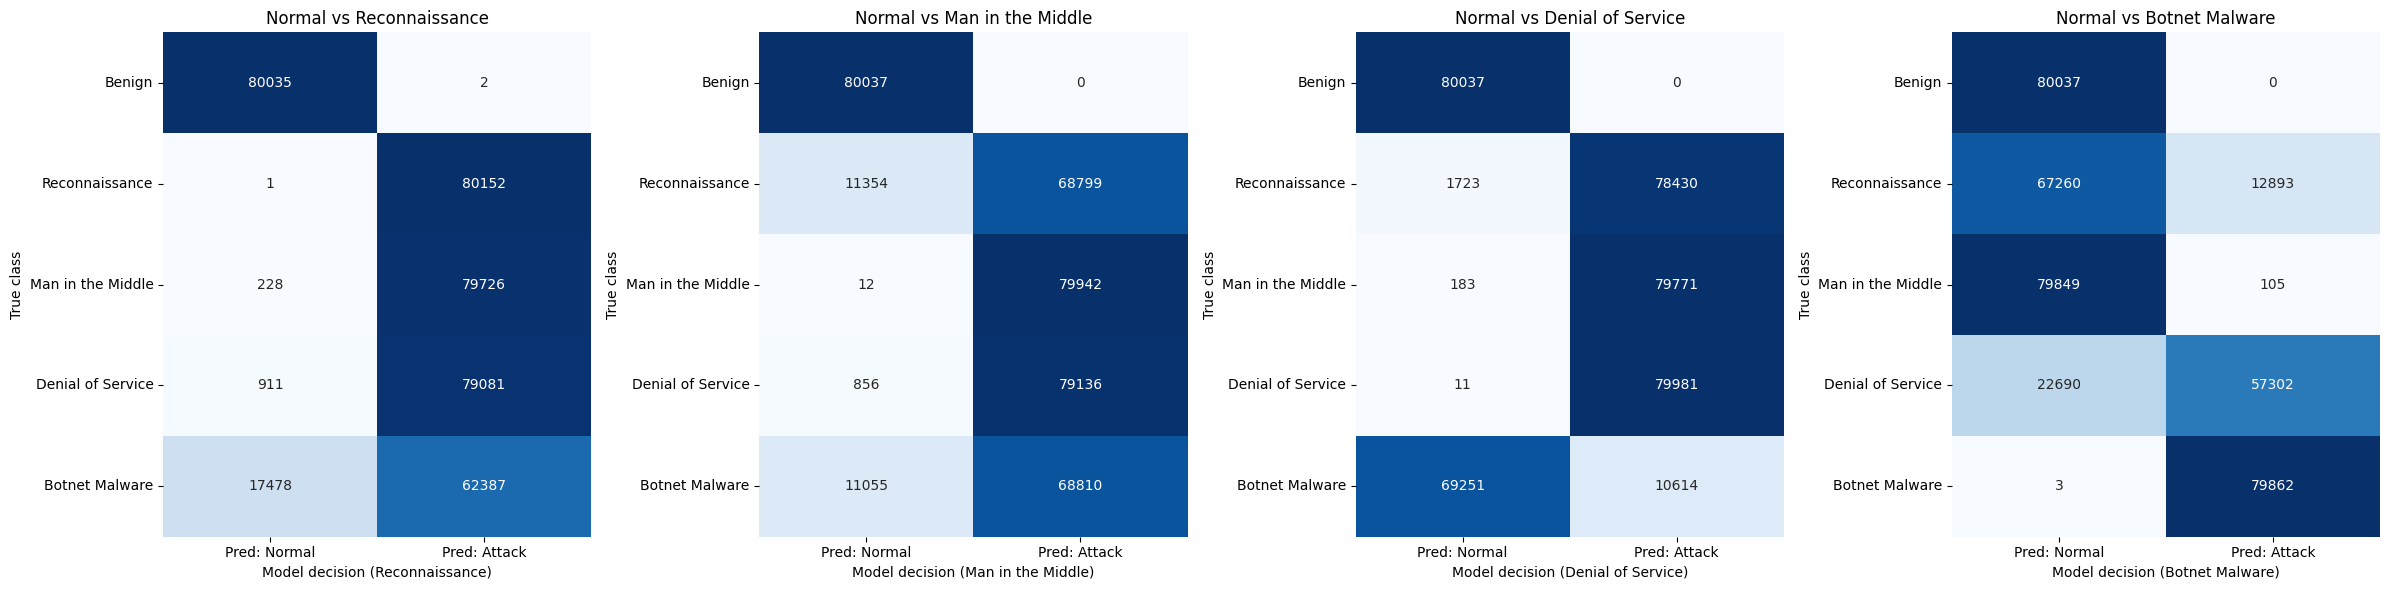

In [10]:
import seaborn as sns
classes_all_names = [
    'Benign',
    'Reconnaissance',
    'Man in the Middle',
    'Denial of Service',
    'Botnet Malware'
]

fig, axes = plt.subplots(1, len(results), figsize=(24,6))

for i, (attack_name, df_cm) in enumerate(results.items()):

    sns.heatmap(
        df_cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        ax=axes[i],
        xticklabels=['Pred: Normal', 'Pred: Attack'],
        yticklabels=classes_all_names
    )

    axes[i].set_title(f'Normal vs {attack_name}')
    axes[i].set_xlabel(f'Model decision ({attack_name})')
    axes[i].set_ylabel('True class')

plt.tight_layout()
plt.show()

In [ ]:
print(df_cm.index)
print(df_cm.columns)

Index([0, 1, 2, 3, 4], dtype='int64', name='True class')
Index([0], dtype='int64', name='Model decision (Benign)')


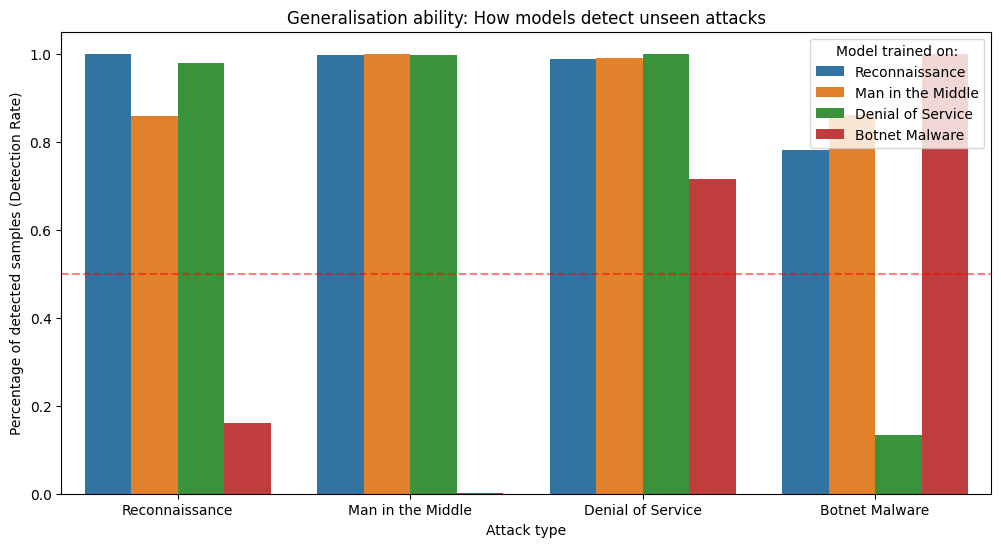

In [12]:

summary_data = []

for model_name, cm in results.items():
    for real_class_id in [1, 2, 3, 4]: 
        total = cm.loc[real_class_id].sum()
        detected = cm.loc[real_class_id, 1] 
        accuracy = detected / total
        
        real_class_name = classes_all_names[real_class_id]
        
        summary_data.append({
            'Model': f'{model_name}',
            'Attack type': real_class_name,
            'Detection Rate': accuracy
        })

df_plot = pd.DataFrame(summary_data)

# Rysowanie
plt.figure(figsize=(12, 6))
sns.barplot(data=df_plot, x='Attack type', y='Detection Rate', hue='Model')
plt.title('Generalisation ability: How models detect unseen attacks')
plt.ylabel('Percentage of detected samples (Detection Rate)')
plt.ylim(0, 1.05)
plt.axhline(0.5, color='red', linestyle='--', alpha=0.5)  # 50% reference line
plt.legend(title='Model trained on:', loc='upper right')
plt.show()